<a href="https://colab.research.google.com/github/aulianur620/Identifikasi-kondisi-finansial-indonesia/blob/main/Identifikasi_Karakteristik_Kondisi_Finansial_Provinsi_di_Indonesia_Menggunakan_Pendekatan_K_Means_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving smart_save.xlsx to smart_save (2).xlsx


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = df.replace('-', np.nan)
df = df.replace('...', np.nan)

df = df.dropna()

df.shape

(33, 5)

In [ ]:
X = df[['Pengeluaran_PerKapita',
        'Dependency_Ratio',
        'Persen_Miskin',
        'Garis_Kemiskinan']]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

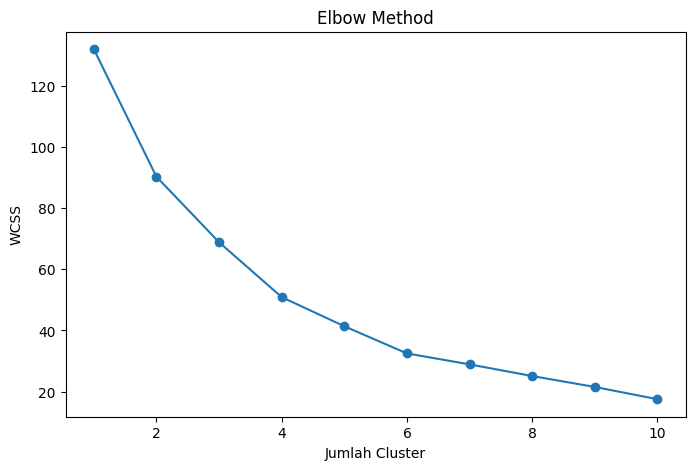

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,'o-')

plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df[['Provinsi','Cluster']]

,Provinsi,Cluster
0,Aceh,0
1,Sumatera Utara,0
2,Sumatera Barat,0
3,Riau,2
4,Jambi,2
5,Sumatera Selatan,0
6,Bengkulu,2
7,Lampung,0
8,Kepulauan Bangka Belitung,1
9,Kepulauan Riau,1


In [ ]:
cluster_summary = df.groupby('Cluster')[[
    'Pengeluaran_PerKapita',
    'Dependency_Ratio',
    'Persen_Miskin',
    'Garis_Kemiskinan'
]].mean()

cluster_summary

,Pengeluaran_PerKapita,Dependency_Ratio,Persen_Miskin,Garis_Kemiskinan
Cluster,,,,
0,1.316487e+06,51.940000,11.872000,603201.866667
1,2.117074e+06,43.266667,5.440000,915116.666667
2,1.630230e+06,45.193333,9.806667,633651.000000


In [ ]:
mapping = {
    0:'Stabil Finansial',
    1:'Menengah',
    2:'Rentan Finansial'
}

df['Kategori'] = df['Cluster'].map(mapping)

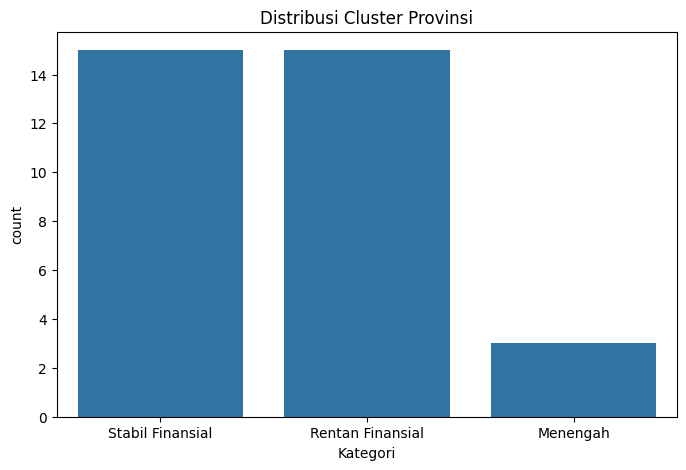

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Kategori'
)

plt.title('Distribusi Cluster Provinsi')

plt.show()

In [ ]:
df.to_excel(
    'hasil_clustering.xlsx',
    index=False
)

In [ ]:
cluster_summary = df.groupby('Cluster')[[
    'Pengeluaran_PerKapita',
    'Dependency_Ratio',
    'Persen_Miskin',
    'Garis_Kemiskinan'
]].mean()

cluster_summary.round(2)

,Pengeluaran_PerKapita,Dependency_Ratio,Persen_Miskin,Garis_Kemiskinan
Cluster,,,,
0,1316487.08,51.94,11.87,603201.87
1,2117074.50,43.27,5.44,915116.67
2,1630230.36,45.19,9.81,633651.00


In [ ]:
mapping = {
    0:'Stabil Finansial',
    1:'Menengah',
    2:'Rentan Finansial'
}

df['Kategori'] = df['Cluster'].map(mapping)

In [ ]:
for kategori in df['Kategori'].unique():
    print("\n")
    print(kategori)

    display(
        df[df['Kategori']==kategori][['Provinsi']]
    )



Stabil Finansial


,Provinsi
0,Aceh
1,Sumatera Utara
2,Sumatera Barat
5,Sumatera Selatan
7,Lampung
12,Jawa Tengah
17,Nusa Tenggara Barat
18,Nusa Tenggara Timur
25,Sulawesi Tengah
26,Sulawesi Selatan




Rentan Finansial


,Provinsi
3,Riau
4,Jambi
6,Bengkulu
11,Jawa Barat
13,DI Yogyakarta
14,Jawa Timur
15,Banten
16,Bali
19,Kalimantan Barat
20,Kalimantan Tengah




Menengah


,Provinsi
8,Kepulauan Bangka Belitung
9,Kepulauan Riau
22,Kalimantan Timur


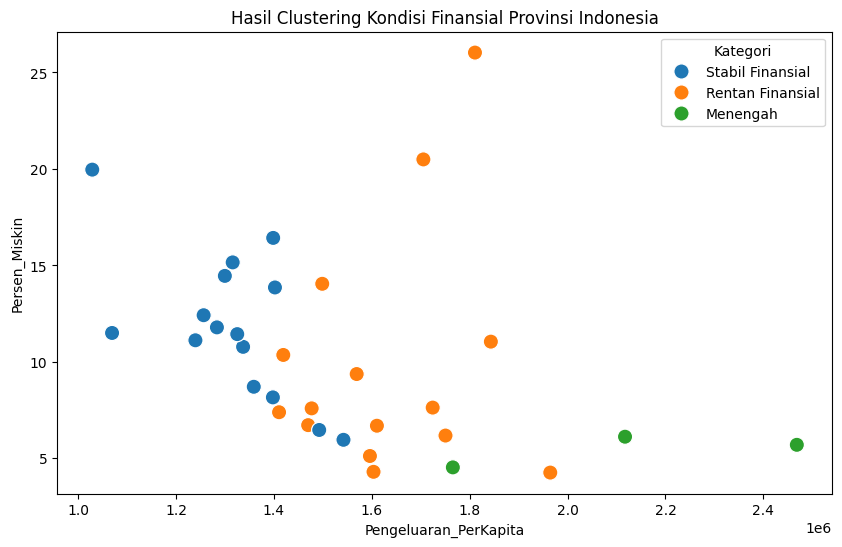

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Pengeluaran_PerKapita',
    y='Persen_Miskin',
    hue='Kategori',
    s=120
)

plt.title('Hasil Clustering Kondisi Finansial Provinsi Indonesia')

plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

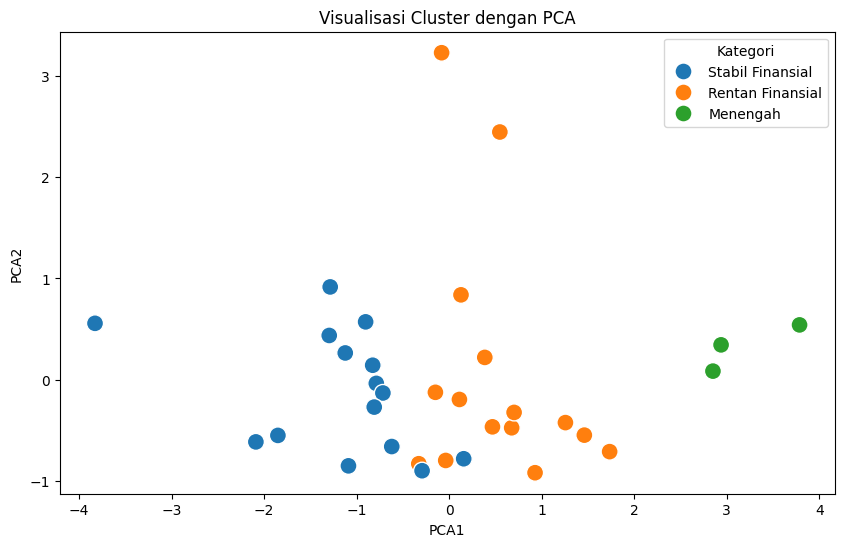

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Kategori',
    s=150
)

plt.title('Visualisasi Cluster dengan PCA')

plt.show()